# 2차시 실습 — 요구사항 명확화 · 문제 구조화 · 데이터 준비 (I)

**인공지능플랫폼 실습/설계 · 2026학년도 2학기**

---

## 이 실습의 목적

머신러닝 시스템 설계 7단계 중 **1~3단계**를 HR 이직 예측 사례에 적용한다.

| 단계 | 이름 | 이 노트북에서 하는 일 |
|---|---|---|
| 1 | 요구사항 명확화 | 모호한 요청을 6가지 축의 질문으로 좁혀 **요구사항 명세 카드** 작성 |
| 2 | ML 작업으로 문제 구조화 | ML 목표·입출력·학습유형을 정하고 **ML 문제 정의 카드** 작성 |
| 3 | 데이터 준비 (I) | 데이터 적재·스키마 검증·EDA 로 **데이터 카드** 작성 |

> **중요** — 이 실습의 결과물은 그래프가 아니라 **세 장의 설계 카드**다.
> 3·4차시 실습이 이 카드들을 이어받아 진행된다.

---

## 사용 데이터

`http://joy-bae.github.io/HR-Employee-Attrition.csv` — 직원 인사기록 1,470건 × 20개 속성

| 속성 | 의미 | 속성 | 의미 |
|---|---|---|---|
| Age | 나이 | OverTime | 초과 근무 여부 (Yes/No) |
| **Attrition** | **이직 여부 (목표 변수)** | p_SalaryHike | 급여 인상 비율(%) |
| Department | 근무 부서 | Performance | 성과 평가 등급 (1~4) |
| Dist | 집~회사 거리 | RelationshipSatisfaction | 동료 관계 만족도 (1~4) |
| Education | 학력 (1~5) | StockOption | 주식 옵션 수준 (0~3) |
| Env_Satisfaction | 환경 만족도 (1~4) | WorkLifeBalance | 일-생활 균형 (1~4) |
| Gender | 성별 | YearsAtCompany | 현 회사 근속 연수 |
| JobLevel | 직급 | YearsSinceLastPromotion | 마지막 승진 이후 경과 연수 |
| JobSatisfaction | 직업 만족도 (1~4) | Income_M | 월급 |
| MaritalStatus | 결혼 여부 | Companies | 이전 근무 회사 수 |


In [119]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


In [120]:
# ============================================================
# 0. 환경 설정 (Colab 에서 런타임을 다시 연결할 때마다 실행)
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 한글 폰트 설정 (Colab/Linux, macOS, Windows 공용) --------
import matplotlib.font_manager as fm, os, subprocess, platform

def setup_korean_font():
    system = platform.system()

    if system == "Darwin":  # macOS — 기본 내장 한글 폰트 사용
        plt.rcParams["font.family"] = "AppleGothic"

    elif system == "Windows":
        plt.rcParams["font.family"] = "Malgun Gothic"

    else:  # Linux/Colab — 나눔고딕 설치 후 사용
        path = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
        if not os.path.exists(path):
            try:
                subprocess.run(["apt-get", "install", "-y", "fonts-nanum"],
                               check=False, capture_output=True)
            except Exception:
                pass
        if os.path.exists(path):
            fm.fontManager.addfont(path)
            plt.rcParams["font.family"] = "NanumBarunGothic"

    plt.rc("axes", unicode_minus=False)

setup_korean_font()
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"][0]
              if isinstance(plt.rcParams["font.family"], list) else plt.rcParams["font.family"])
plt.rc("axes", unicode_minus=False)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

RANDOM_STATE = 2026
DATA_URL = "http://joy-bae.github.io/HR-Employee-Attrition.csv"
print("환경 설정 완료 / pandas", pd.__version__)

환경 설정 완료 / pandas 2.3.3


---
# STEP 1 · 요구사항 명확화

## 상황

> OOO사 인사팀: **"요즘 직원들이 너무 많이 나갑니다. 인사기록 데이터가 있으니 AI로 어떻게 좀 해주세요."**

이것은 요구사항이 아니라 **불편함의 호소**다. 설계자는 여기서부터 질문을 시작한다.

## 실습 1-1. 명확화 질문 만들기

아래 6가지 축에 대해, 인사팀에게 **실제로 물어야 할 질문**을 각각 1개 이상 적어라.
(강의자료의 예시를 그대로 옮기지 말고, 이 사례에 맞게 구체적으로 쓸 것)


### [작성] 명확화 질문

아래 표의 빈칸을 채워라.

| 축 | 내가 물어볼 질문 | 인사팀의 답(가정) |
|---|---|---|
| 비즈니스 목표 |  |  |
| 피처 |  |  |
| 데이터 |  |  |
| 제약 |  |  |
| 시스템 규모 |  |  |
| 기대 성능 |  |  |


## 실습 1-2. 요구사항 명세 카드 (산출물 ①)

위 질문의 답을 정리해 아래 카드를 완성하라.
**"하지 않을 것"** 항목을 반드시 채울 것 — 시스템의 경계를 명시하지 않으면 예측 결과가 원래 의도와 다른 용도로 쓰이는 것을 막을 수 없다.


### [산출물 ①] 요구사항 명세 카드

- **문제 이름** : 직원 자발적 퇴사(이직) 위험 예측
- **요청자 / 사용자** : 인사팀 (예측 결과의 실제 사용자)
- **비즈니스 목표** : 핵심 인재 이탈로 인한 채용 ・ 교육 재투자 비용 절감
- **성공의 정의** : 면담 대상 선정의 적중률 향상, 6개월 내 자발적 퇴사율 감소
- **사용 가능 데이터** : HRIS 인사기록 1,470건 x 20개 속성 (라벨 포함)
- **제약** : 사내 서버 1대, GPU 없음, 월 1회 배치, 예측 근거 설명 필요
- **규모** : 전 직원 수천 명 / 월 1회 / 실시간 요구 없음
- **성능 우선순위** : 재현율(놓치지 않기) > 정밀도 > 대기시간
- **하지 않을 것** : 개인에 대한 자동 인사 조치, 성별 ・ 연령 기반 차등 처우, 예측 결과의 본인 통보

**합의문 한 줄**
> 매월 전 직원의 6개월 내 자발적 퇴사 위험을 예측해, 위험도 상위 인원을 인사팀 면담 대상으로 제시한다. </br> 놓치는 퇴사자를 줄이는 것이 우선이며, 예측 근거를 설명할 수 있어야 한다. 


### 6개월 내 자발적 퇴사율 감소
- 자발적 퇴사율 항목이 없어서 사실상 판단할 수 X
- 합의문에서는 하지 않을 것에 대한 내용이 없어서 이러면 X

---
# STEP 2 · 머신러닝 작업으로 문제 구조화

## 실습 2-1. 머신러닝이 필요한가?

아래 네 조건을 이 사례에 대해 판정하라.

| 조건 | 판정 (O/X) | 근거 |
|---|---|---|
| ① 데이터에 패턴이 존재하는가 | O | |
| ② 규칙으로 명시하기 어려운가 | O | |
| ③ 라벨이 붙은 데이터가 있는가 | O | |
| ④ 반복적으로 필요한 판단인가 | O | |


### [작성] 판정 결과

| 조건 | 판정 | 근거 |
|---|---|---|
| ① 패턴 존재 |  O |  |
| ② 규칙화 어려움 |  O |  |
| ③ 라벨 존재 |  O |  |
| ④ 반복 필요 |  O |  |

**결론**:


## 실습 2-2. ML 문제 정의 카드 (산출물 ②)

비즈니스 목표를 머신러닝 목표로 **번역**하라.
머신러닝 목표에는 반드시 **예측 대상(무엇을)** · **예측 단위(누구마다)** · **예측 시점(언제)** 이 들어가야 한다.


### [산출물 ②] ML 문제 정의 카드

- **ML 목표** : 직원 1명의 인사기록으로 6개월 내 자발적 퇴사 확률을 예측
- **학습 유형** : 지도학습· 이진 분류
- **예측 단위** : 직원 1명 (행 1개 = 직원 1명)
- **입력 X** : 인사기록 19개 속성 (Attrition 제외)
- **출력 y** : P(퇴사) ∈ [0, 1] — 이후 임계값으로 Yes/No 결정
- **라벨 정의** : Attrition = 1 (퇴사), 0 (재직)
- **사용 금지 피처** : 예측 시점 이후에 확정되는 값 (누수 방지)
- **주 지표** : Recall / PR-AUC (보조: Precision, F1, ROC-AUC)
- **기준선** : "전원 재직으로 예측" → 아래 STEP 3-D에서 실제 수치로 확인한다.

**왜 회귀·군집화가 아닌가** (선택하지 않은 이유를 각각 한 문장으로)
- 회귀(퇴사까지 남은 개월 수): 잔류 중인 직원의 정답이 존재하지 않아 라벨을 만들 수 없다.
- 군집화: 개인별 위험도 순위를 만들 수 없어 "면담 대상 선정"이라는 요구사항을 충족하지 못한다.
- 다중 분류(자발/비자발/잔류): 현재 라벨이 퇴사 사유를 구분하지 않는다 → 데이터가 허용하지 않는 구조화.


---
# STEP 3 · 데이터 준비 (I)

## 3-A. 데이터 적재와 스키마 검증

1차시 그림 1.1 의 머신러닝 시스템에는 `Data Collection` 옆에 **`Data Verification`** 블록이 따로 있었다.
학습을 시작하기 전에 데이터가 **우리가 기대한 계약(contract)** 을 지키는지 코드로 확인한다.

> 여기서 만드는 `validate()` 함수는 **4차시 배포·모니터링에서 그대로 재사용**한다.


# 수업들으며 타이핑
<div width="40px"> 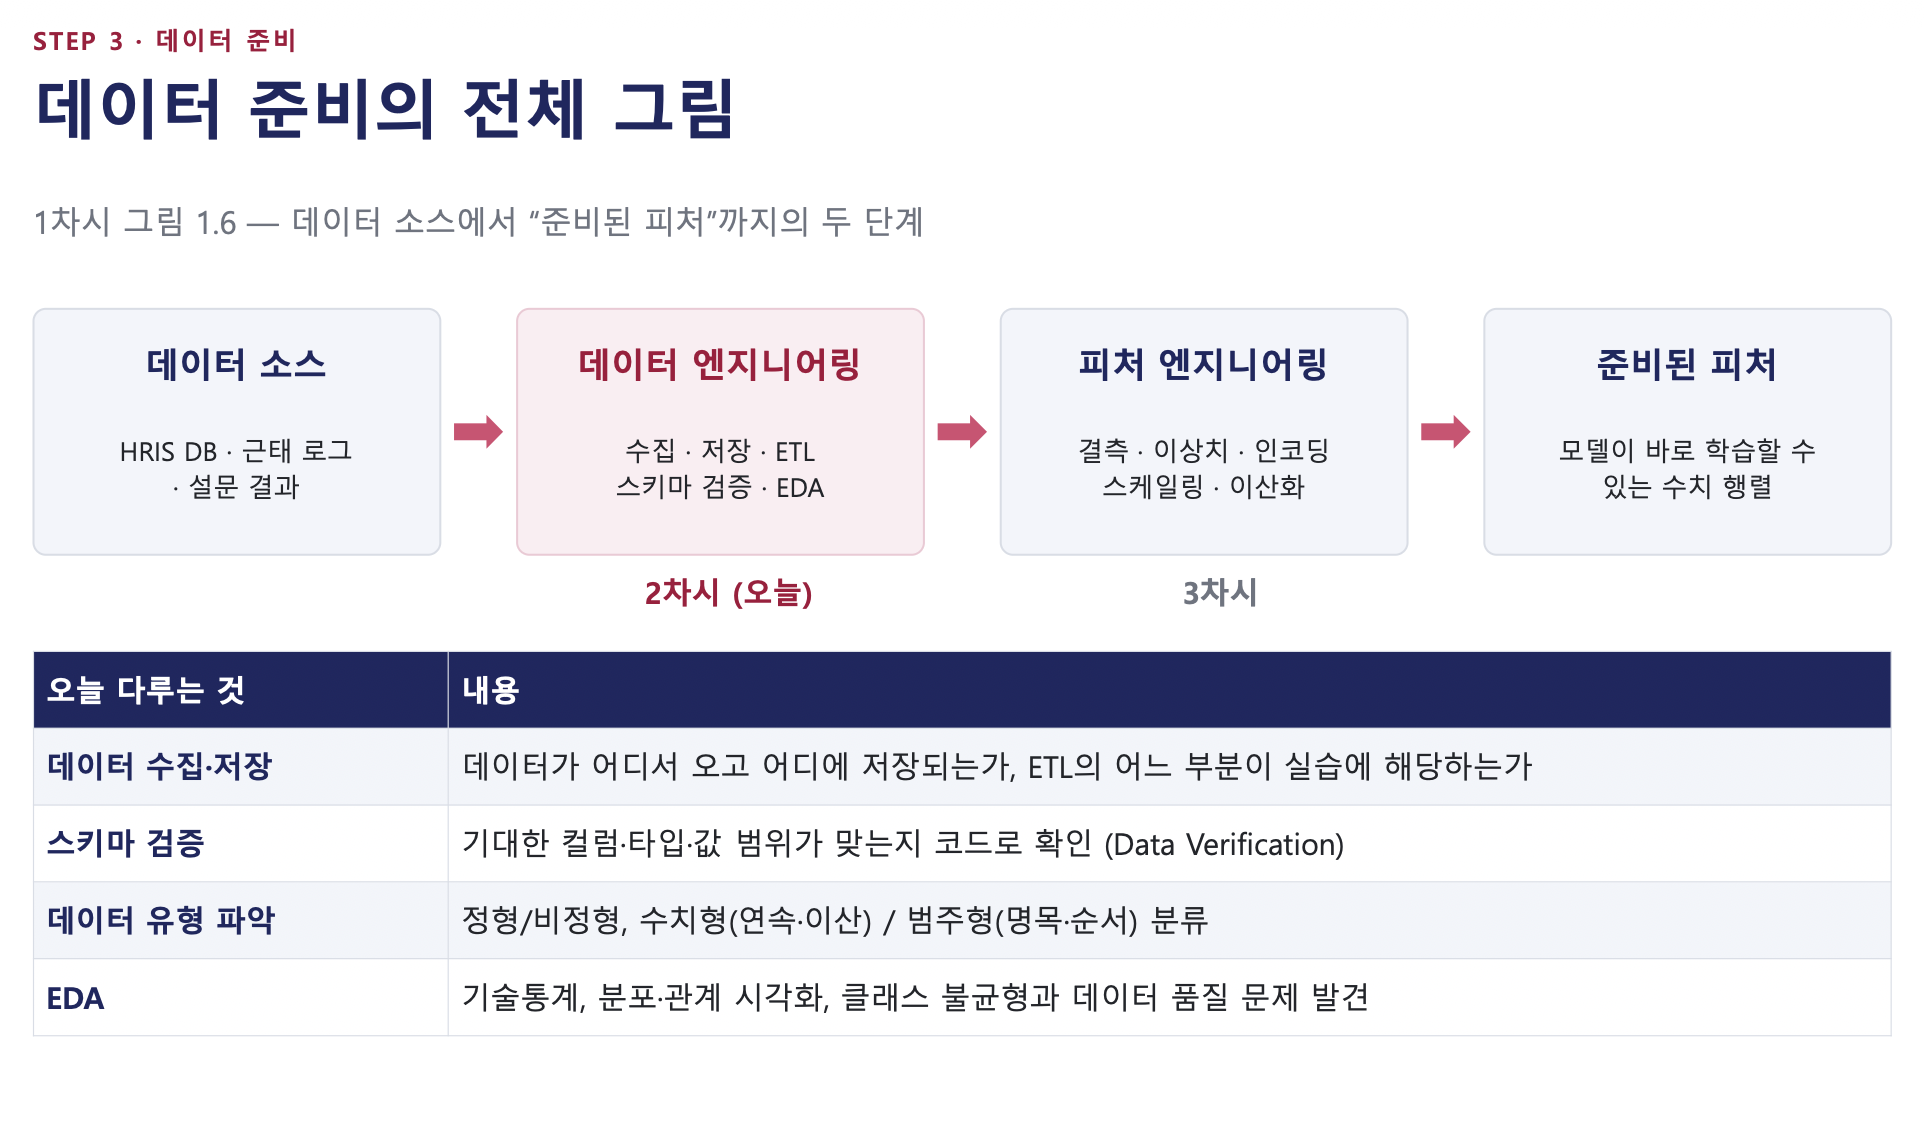 </div>
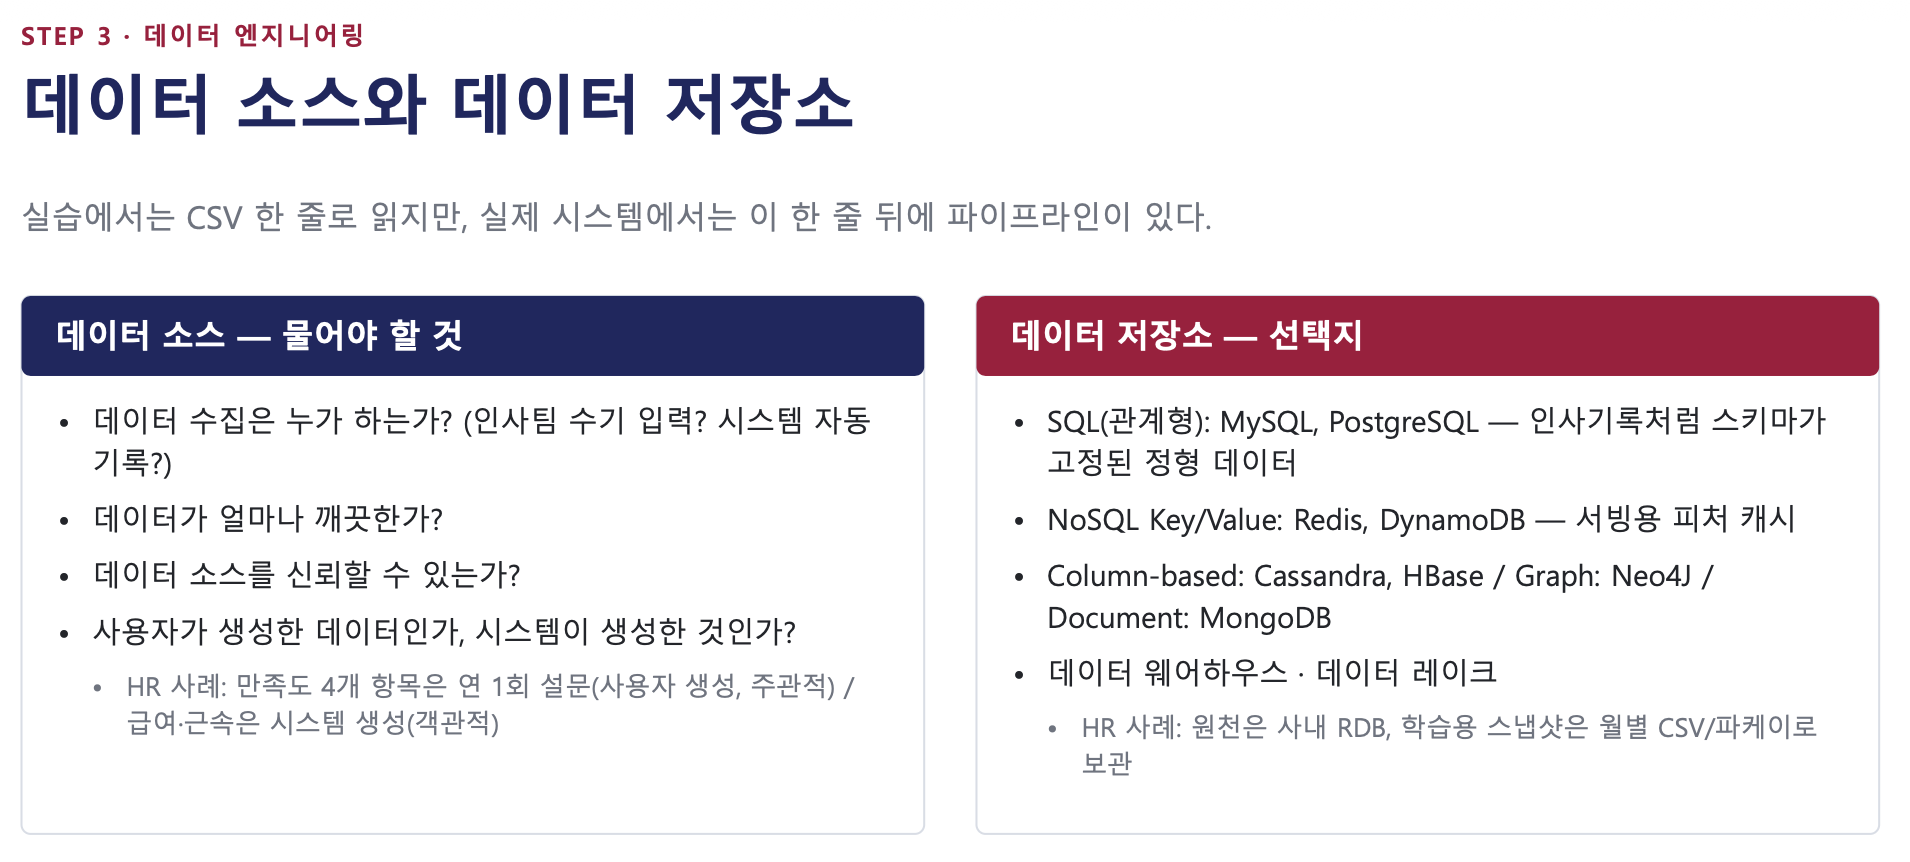
> 데이터를 누가 수집하는지, 이미지에 노이즈가 있는지, 소스를 신뢰할 수 있는 지, 사용자가 생성한 것인지 등등을 알아서 수집할 수 있어야함. <- 이런 데이터들은 데이터 웨어하우스에 있는 데이터인지 어떤 형식의 데이터인지 알아서 추출해낼 수 있어야함.
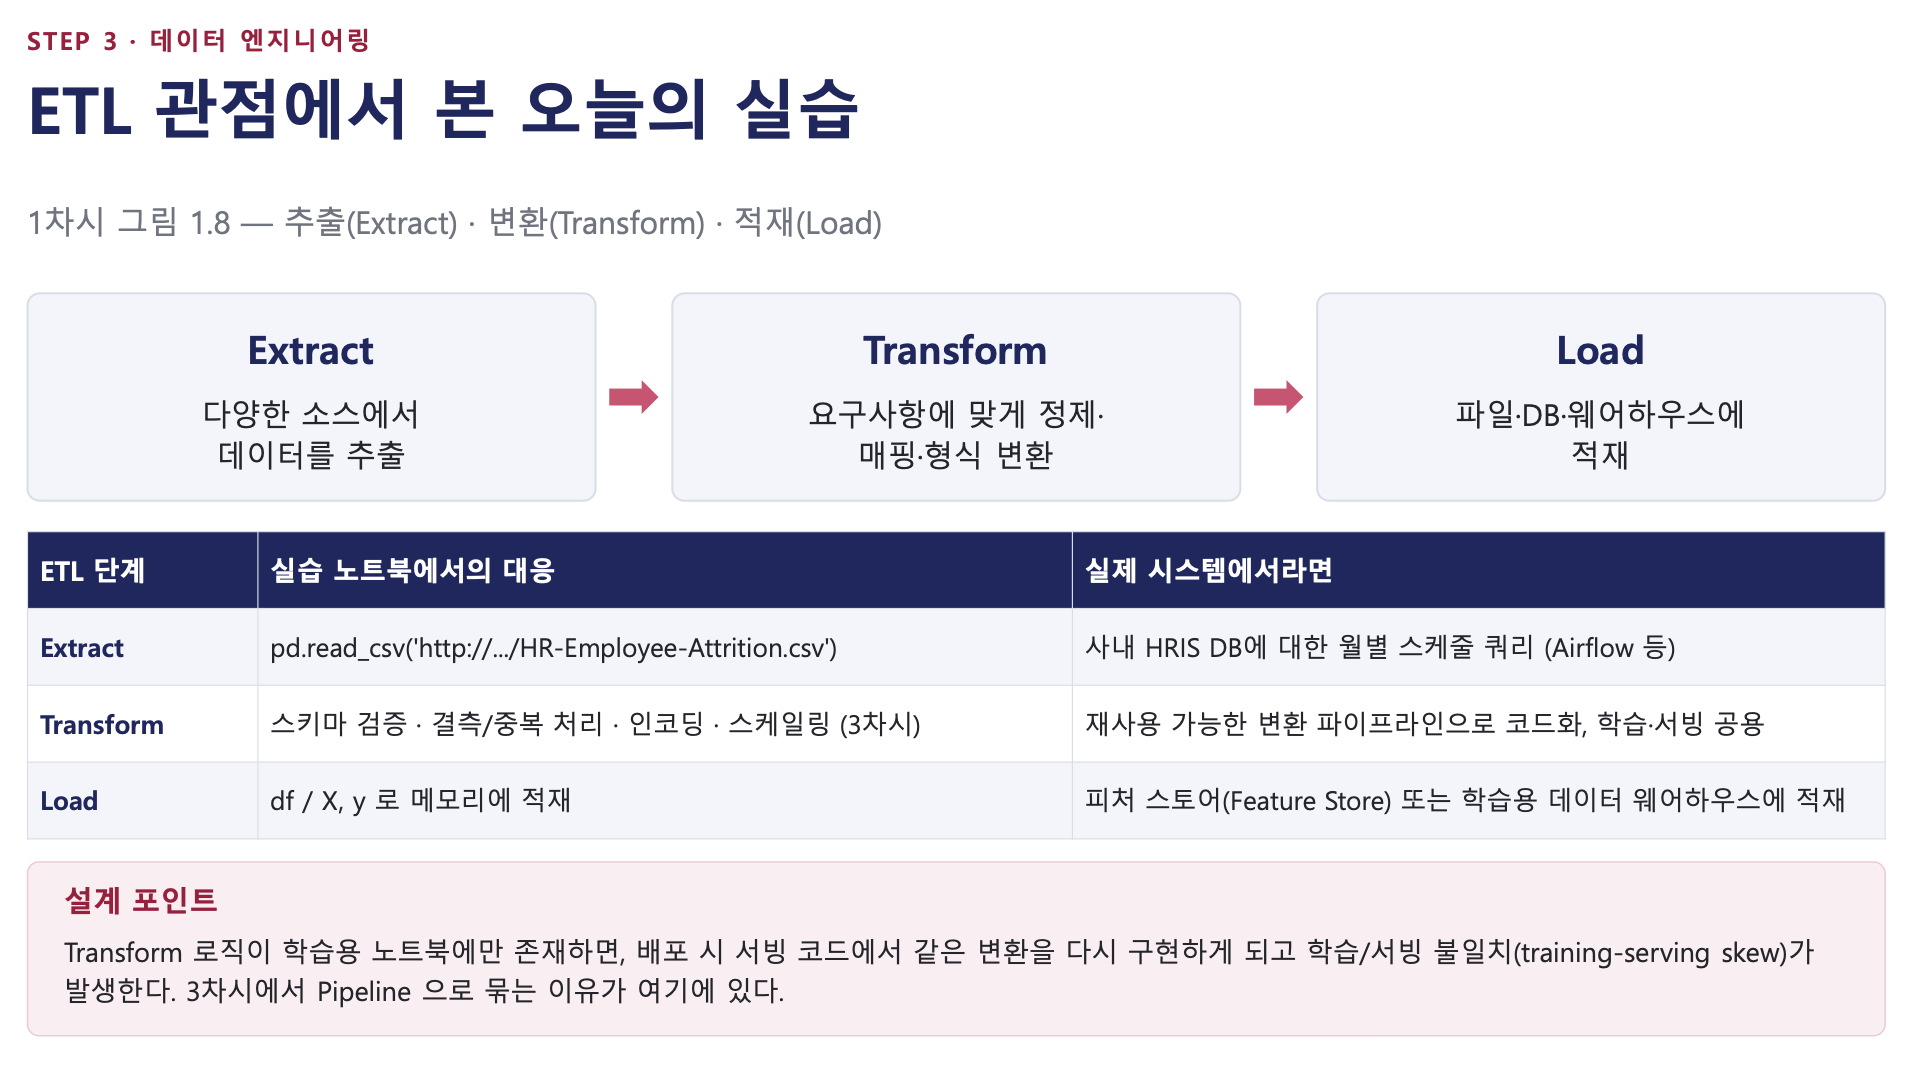


In [121]:
# 데이터 적재
df=pd.read_csv(DATA_URL)
print("shape:", df.shape)


shape: (1470, 20)


In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   Department                1470 non-null   object
 3   Dist                      1470 non-null   int64 
 4   Education                 1470 non-null   int64 
 5   Env_Satisfaction          1470 non-null   int64 
 6   Gender                    1470 non-null   object
 7   JobLevel                  1470 non-null   int64 
 8   JobSatisfaction           1470 non-null   int64 
 9   MaritalStatus             1470 non-null   object
 10  Income_M                  1470 non-null   int64 
 11  Companies                 1470 non-null   int64 
 12  OverTime                  1470 non-null   object
 13  p_SalaryHike              1470 non-null   int64 
 14  Performance             

### 실습 3-1. 스키마 검증 함수 구현

`EXPECTED_SCHEMA` 를 참고해 `validate(df, schema)` 함수를 완성하라.

- 규칙이 `("num", lo, hi)` 이면 → 값이 `[lo, hi]` 범위를 벗어난 건수를 센다
- 규칙이 `("cat", {허용값})` 이면 → 허용값 집합에 없는 값이 있는지 확인한다
- 컬럼 자체가 없으면 `[누락]` 항목을 기록한다
- 문제가 없으면 빈 리스트를 반환한다


In [123]:
EXPECTED_SCHEMA = {
    "Age":                      ("num", 18, 65),
    "Attrition":                ("num", 0, 1),
    "Department":               ("cat", {"Sales", "Research & Development", "Human Resources"}),
    "Dist":                     ("num", 1, 30),
    "Education":                ("num", 1, 5),
    "Env_Satisfaction":         ("num", 1, 4),
    "Gender":                   ("cat", {"Male", "Female"}),
    "JobLevel":                 ("num", 1, 5),
    "JobSatisfaction":          ("num", 1, 4),
    "MaritalStatus":            ("cat", {"Single", "Married", "Divorced"}),
    "Income_M":                 ("num", 1000, 20000),
    "Companies":                ("num", 0, 10),
    "OverTime":                 ("cat", {"Yes", "No"}),
    "p_SalaryHike":             ("num", 10, 25),
    "Performance":              ("num", 1, 4),
    "RelationshipSatisfaction": ("num", 1, 4),
    "StockOption":              ("num", 0, 3),
    "WorkLifeBalance":          ("num", 1, 4),
    "YearsAtCompany":           ("num", 0, 45),
    "YearsSinceLastPromotion":  ("num", 0, 20),
}


def validate(data, schema):
    """데이터가 기대한 스키마를 지키는지 확인하고 문제 목록을 반환한다."""
    issues = []
    for col, rule in schema.items():
        # TODO 1) 컬럼이 없으면 "[누락] ..." 메시지를 issues 에 추가하고 continue
        # TODO 2) rule[0] == "cat" 이면 허용값 집합(rule[1])에 없는 값이 있는지 확인
        # TODO 3) rule[0] == "num" 이면 [rule[1], rule[2]] 범위를 벗어난 건수를 확인
        # TODO 4) 결측치가 있으면 "[결측] ..." 메시지를 추가
        pass
    return issues


issues = validate(df, EXPECTED_SCHEMA)
print("검증 결과:", "이상 없음 " if not issues else "")
for i in issues:
    print(" -", i)

검증 결과: 이상 없음 


In [124]:
# ─────────────────────────────────────────────────────────────
#  구제 셀 — validate() 스키마 검증 함수
#  위 TODO 를 완성했다면 이 셀은 그냥 실행하고 지나가면 된다 (아무 일도 일어나지 않는다).
#  막혔다면 USE_RESCUE 를 True 로 바꾸고 실행한 뒤 다음 절로 진행한다.
#  ※ 제출 시 True 로 두어도 감점하지 않는다. 다만 어디서 막혔는지는 기록해 둘 것.
# ─────────────────────────────────────────────────────────────
USE_RESCUE = True

if USE_RESCUE:
    def validate(data, schema):
        issues = []
        for col, rule in schema.items():
            if col not in data.columns:
                issues.append(f"[누락] 컬럼 '{col}' 이 없습니다")
                continue
            if rule[0] == "cat":
                unknown = set(data[col].dropna().unique()) - rule[1]
                if unknown:
                    issues.append(f"[값] {col}: 예상 밖의 값 {unknown}")
            else:
                lo, hi = rule[1], rule[2]
                if not pd.api.types.is_numeric_dtype(data[col]):
                    issues.append(f"[타입] {col}: 수치형이어야 하는데 {data[col].dtype} 입니다")
                    continue
                n_bad = int(((data[col] < lo) | (data[col] > hi)).sum())
                if n_bad:
                    issues.append(f"[범위] {col}: [{lo}, {hi}] 범위를 벗어난 값 {n_bad}건")
            n_na = int(data[col].isna().sum())
            if n_na:
                issues.append(f"[결측] {col}: 결측치 {n_na}건")
        return issues

    issues = validate(df, EXPECTED_SCHEMA)
    print("검증 결과:", "이상 없음" if not issues else issues)
    print('구제 코드를 사용했습니다 — validate() 스키마 검증 함수')

검증 결과: 이상 없음
구제 코드를 사용했습니다 — validate() 스키마 검증 함수


### 실습 3-2. 검증 함수가 정말 동작하는지 확인하기

검증 함수는 **문제가 있는 데이터를 넣었을 때 실제로 잡아내는지**를 확인해야 의미가 있다.
일부러 오염시킨 데이터를 만들어 넣어 보자.


In [125]:
# 일부러 망가뜨린 데이터로 검증 함수를 시험한다 (운영 데이터에서 실제로 일어나는 일들)
broken = df.copy()
broken.loc[0, "Age"] = 150                      # 범위 이탈
broken.loc[1, "Department"] = "Marketing"       # 학습 때 없던 새 부서
broken.loc[2, "Income_M"] = np.nan              # 결측 발생
broken = broken.drop(columns=["StockOption"])   # 컬럼 삭제

for i in validate(broken, EXPECTED_SCHEMA):
    print(" -", i)

 - [범위] Age: [18, 65] 범위를 벗어난 값 1건
 - [값] Department: 예상 밖의 값 {'Marketing'}
 - [결측] Income_M: 결측치 1건
 - [누락] 컬럼 'StockOption' 이 없습니다


---
## 3-B. 기술통계와 속성 유형 분류  - 9/15(화) 시작

속성이 **수치형인지 범주형인지, 순서가 있는지 없는지**에 따라 3차시의 인코딩·스케일링 방식이 결정된다.

> 주의 — **숫자로 저장되어 있다고 수치형이 아니다.**
> `Education = 5` 가 `Education = 1` 보다 "5배"인 것은 아니다. 순서형 범주는 순서만 의미가 있다.


In [126]:
# 데이터 구조, 타입, 결측치 등을 확인한다
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   Department                1470 non-null   object
 3   Dist                      1470 non-null   int64 
 4   Education                 1470 non-null   int64 
 5   Env_Satisfaction          1470 non-null   int64 
 6   Gender                    1470 non-null   object
 7   JobLevel                  1470 non-null   int64 
 8   JobSatisfaction           1470 non-null   int64 
 9   MaritalStatus             1470 non-null   object
 10  Income_M                  1470 non-null   int64 
 11  Companies                 1470 non-null   int64 
 12  OverTime                  1470 non-null   object
 13  p_SalaryHike              1470 non-null   int64 
 14  Performance             

In [127]:
df.describe()

,Age,Attrition,Dist,Education,Env_Satisfaction,JobLevel,JobSatisfaction,Income_M,Companies,p_SalaryHike,Performance,RelationshipSatisfaction,StockOption,WorkLifeBalance,YearsAtCompany,YearsSinceLastPromotion
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,0.161224,9.192517,2.912925,2.721769,2.063946,2.728571,6502.931293,2.693197,15.209524,3.153741,2.712245,0.793878,2.761224,7.008163,2.187755
std,9.135373,0.367863,8.106864,1.024165,1.093082,1.106940,1.102846,4707.956783,2.498009,3.659938,0.360824,1.081209,0.852077,0.706476,6.126525,3.222430
min,18.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1009.000000,0.000000,11.000000,3.000000,1.000000,0.000000,1.000000,0.000000,0.000000
25%,30.000000,0.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2911.000000,1.000000,12.000000,3.000000,2.000000,0.000000,2.000000,3.000000,0.000000
50%,36.000000,0.000000,7.000000,3.000000,3.000000,2.000000,3.000000,4919.000000,2.000000,14.000000,3.000000,3.000000,1.000000,3.000000,5.000000,1.000000
75%,43.000000,0.000000,14.000000,4.000000,4.000000,3.000000,4.000000,8379.000000,4.000000,18.000000,3.000000,4.000000,1.000000,3.000000,9.000000,3.000000
max,60.000000,1.000000,29.000000,5.000000,4.000000,5.000000,4.000000,19999.000000,9.000000,25.000000,4.000000,4.000000,3.000000,4.000000,40.000000,15.000000


In [128]:
# 수치형 기술통계 (기술통계란 데이터의 중심 경향, 분포, 범위 등을 요약한 통계량을 의미한다)
# T -> 트랜스포즈
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470.0,0.161224,0.367863,0.0,0.0,0.0,0.0,1.0
Dist,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
Env_Satisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.0,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.0,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.0,4.0
Income_M,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.0,19999.0
Companies,1470.0,2.693197,2.498009,0.0,1.0,2.0,4.0,9.0
p_SalaryHike,1470.0,15.209524,3.659938,11.0,12.0,14.0,18.0,25.0


In [129]:
# 범주형 기술통계 (include="object" 옵션을 주면 범주형 컬럼만 선택된다)
# unique: 고유값 개수, top: 최빈값, freq: 최빈값의 빈도
df.describe(include="object").T

,count,unique,top,freq
Department,1470,3,Research & Development,961
Gender,1470,2,Male,882
MaritalStatus,1470,3,Married,673
OverTime,1470,2,No,1054


In [130]:
# 범주형 데이터의 범주별 빈도수 확인 코드
# df['Department'].value_counts()

# 정렬
# df['Department'].value_counts().sort_values(ascending=False) #내림차순
df['Department'].value_counts().sort_values(ascending=True) #오름차순
# df['Department'].value_counts(normalize=True)  # normalize=True 옵션을 주면 비율로 확인 가능

Department
Human Resources            63
Sales                     446
Research & Development    961
Name: count, dtype: int64

In [131]:
df.select_dtypes(include="object").columns

Index(['Department', 'Gender', 'MaritalStatus', 'OverTime'], dtype='object')

In [132]:
# normalize=True 옵션을 주면 비율로 확인 가능

obj_cols = df.select_dtypes(include="object").columns

for col in obj_cols:
    print(df[col].value_counts(normalize=True).sort_values(ascending=False))

# df["Attrition"].value_counts().sort_values(ascending=False)
df["Attrition"].value_counts(normalize=True).sort_values(ascending=False)

Department
Research & Development    0.653741
Sales                     0.303401
Human Resources           0.042857
Name: proportion, dtype: float64
Gender
Male      0.6
Female    0.4
Name: proportion, dtype: float64
MaritalStatus
Married     0.457823
Single      0.319728
Divorced    0.222449
Name: proportion, dtype: float64
OverTime
No     0.717007
Yes    0.282993
Name: proportion, dtype: float64


Attrition
0    0.838776
1    0.161224
Name: proportion, dtype: float64

In [133]:
# df['Department'].value_counts().sort_values(ascending=False) #내림차순
df['Department'].value_counts().sort_values(ascending=True) #오름차순
# df['Department'].value_counts(normalize=True)  # normalize=True 옵션을 주면 비율로 확인 가능

Department
Human Resources            63
Sales                     446
Research & Development    961
Name: count, dtype: int64

### 실습 3-3. 속성 유형 분류표 만들기

아래 4가지 유형으로 20개 컬럼을 모두 분류하는 딕셔너리를 완성하고, 표로 출력하라.

- `num_cont` 수치형·연속형 / `num_disc` 수치형·이산형
- `cat_ord` 범주형·순서형 / `cat_nom` 범주형·명목형


In [134]:
df.select_dtypes(include="object").columns

Index(['Department', 'Gender', 'MaritalStatus', 'OverTime'], dtype='object')

In [135]:
df.dtypes

Age                          int64
Attrition                    int64
Department                  object
Dist                         int64
Education                    int64
Env_Satisfaction             int64
Gender                      object
JobLevel                     int64
JobSatisfaction              int64
MaritalStatus               object
Income_M                     int64
Companies                    int64
OverTime                    object
p_SalaryHike                 int64
Performance                  int64
RelationshipSatisfaction     int64
StockOption                  int64
WorkLifeBalance              int64
YearsAtCompany               int64
YearsSinceLastPromotion      int64
dtype: object

In [136]:
df.nunique().sort_values()

Attrition                      2
Gender                         2
OverTime                       2
Performance                    2
MaritalStatus                  3
Department                     3
WorkLifeBalance                4
Env_Satisfaction               4
JobSatisfaction                4
StockOption                    4
RelationshipSatisfaction       4
Education                      5
JobLevel                       5
Companies                     10
p_SalaryHike                  15
YearsSinceLastPromotion       16
Dist                          29
YearsAtCompany                37
Age                           43
Income_M                    1349
dtype: int64

In [137]:
for c in ["Education", "JobLevel", "StockOption", "Age", "Income_M"]:
    print(c, sorted(df[c].unique()))


Education [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
JobLevel [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
StockOption [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Age [np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60)]
Income_M [np.int64(1009), np.int64(1051), np.int64(1052), np.int64(1081), np.int64(1091), np.int64(1102), np.int64(1118), np.int64(1129), np.int64(1200), np.int64(1223), np.int6

In [138]:
num_like_cols = df.select_dtypes(include="number").columns.drop("Attrition")
df[num_like_cols].agg(['min', 'max', 'nunique'])

,Age,Dist,Education,Env_Satisfaction,JobLevel,JobSatisfaction,Income_M,Companies,p_SalaryHike,Performance,RelationshipSatisfaction,StockOption,WorkLifeBalance,YearsAtCompany,YearsSinceLastPromotion
min,18,1,1,1,1,1,1009,0,11,3,1,0,1,0,0
max,60,29,5,4,5,4,19999,9,25,4,4,3,4,40,15
nunique,43,29,5,4,5,4,1349,10,15,2,4,4,4,37,16


In [139]:
df.select_dtypes(include="int64").columns

Index(['Age', 'Attrition', 'Dist', 'Education', 'Env_Satisfaction', 'JobLevel', 'JobSatisfaction', 'Income_M', 'Companies', 'p_SalaryHike',
       'Performance', 'RelationshipSatisfaction', 'StockOption', 'WorkLifeBalance', 'YearsAtCompany', 'YearsSinceLastPromotion'],
      dtype='object')

In [140]:
# COLUMN_TYPES = {
#     "num_cont": [],   # TODO: 수치형·연속형 컬럼
#     "num_disc": [],   # TODO: 수치형·이산형 컬럼
#     "cat_ord":  [],   # TODO: 범주형·순서형 컬럼 (정수로 저장된 만족도·등급 등)
#     "cat_nom":  ['Department', 'Gender', 'MaritalStatus', 'OverTime'],   # TODO: 범주형·명목형 컬럼 (순서 없는 문자열)
# }

COLUMN_TYPES = {
    "num_cont": ["Income_M", "p_SalaryHike"],   # 수치형·연속형 컬럼
    "num_disc": ["Age", "Dist", "Companies", "YearsAtCompany", "YearsSinceLastPromotion"],   # 수치형·이산형 컬럼
    "cat_ord":  ["Education", "JobLevel", "JobSatisfaction", "Env_Satisfaction",
                 "RelationshipSatisfaction", "Performance", "StockOption", "WorkLifeBalance"],   # 범주형·순서형 컬럼 (정수로 저장된 만족도·등급 등)
    "cat_nom":  ['Department', 'Gender', 'MaritalStatus', 'OverTime'],   # 범주형·명목형 컬럼 (순서 없는 문자열)
}

TARGET = "Attrition"

# 분류 누락 확인
classified = sum(COLUMN_TYPES.values(), []) + [TARGET]
missing = set(df.columns) - set(classified)
extra = set(classified) - set(df.columns)
print("분류되지 않은 컬럼:", missing if missing else "없음 ")
print("데이터에 없는 컬럼:", extra if extra else "없음 ")

label = {"num_cont": "수치형·연속형", "num_disc": "수치형·이산형",
         "cat_ord": "범주형·순서형", "cat_nom": "범주형·명목형"}
plan = {"num_cont": "스케일링 (왜도 크면 로그/로버스트 검토)",
        "num_disc": "스케일링 또는 버킷팅(이산화)",
        "cat_ord":  "정수 그대로 사용 (순서 의미 보존)",
        "cat_nom":  "원-핫 인코딩 (2범주는 라벨 인코딩)"}

type_table = pd.DataFrame(
    [{"컬럼": c, "유형": label[k], "고유값 수": df[c].nunique(),
      "3차시 처리 계획": plan[k]}
     for k, cols in COLUMN_TYPES.items() for c in cols]
)
type_table

분류되지 않은 컬럼: 없음 
데이터에 없는 컬럼: 없음 


,컬럼,유형,고유값 수,3차시 처리 계획
0,Income_M,수치형·연속형,1349,스케일링 (왜도 크면 로그/로버스트 검토)
1,p_SalaryHike,수치형·연속형,15,스케일링 (왜도 크면 로그/로버스트 검토)
2,Age,수치형·이산형,43,스케일링 또는 버킷팅(이산화)
3,Dist,수치형·이산형,29,스케일링 또는 버킷팅(이산화)
4,Companies,수치형·이산형,10,스케일링 또는 버킷팅(이산화)
5,YearsAtCompany,수치형·이산형,37,스케일링 또는 버킷팅(이산화)
6,YearsSinceLastPromotion,수치형·이산형,16,스케일링 또는 버킷팅(이산화)
7,Education,범주형·순서형,5,정수 그대로 사용 (순서 의미 보존)
8,JobLevel,범주형·순서형,5,정수 그대로 사용 (순서 의미 보존)
9,JobSatisfaction,범주형·순서형,4,정수 그대로 사용 (순서 의미 보존)


### 참고 — 원-핫 인코딩(One-Hot Encoding)이란?

`cat_nom`(명목형) 컬럼은 순서가 없는 문자열 범주다. 모델은 문자열을 직접 이해하지 못하므로 숫자로 바꿔야 하는데,
`Department`를 그냥 `{Sales:0, R&D:1, HR:2}` 처럼 정수로 바꾸면 모델이 "R&D(1)가 Sales(0)보다 크다"는
**없는 순서·크기 관계**를 학습해버린다. 이를 막기 위해 범주마다 0/1 값을 갖는 **별도 컬럼**을 만드는 것이 원-핫 인코딩이다.

예를 들어 `Department` (Sales / Research & Development / Human Resources) 를 원-핫 인코딩하면:

| Department | Dept_Sales | Dept_R&D | Dept_HR |
|---|---|---|---|
| Sales | 1 | 0 | 0 |
| Research & Development | 0 | 1 | 0 |
| Human Resources | 0 | 0 | 1 |

- 각 행에서 자신이 속한 범주의 컬럼만 1, 나머지는 0 → "한(One) 곳만 뜨거운(Hot) 값" 이라서 원-핫
- 범주가 2개뿐인 컬럼(`Gender`, `OverTime`)은 굳이 2개 컬럼을 만들 필요 없이 0/1 하나로 표현해도 정보 손실이 없음 → `plan` 딕셔너리의 "2범주는 라벨 인코딩" 메모가 이 얘기
- `cat_ord`(순서형, 예: `Education` 1~5)는 반대로 원-핫을 하지 않고 정수를 그대로 쓴다 — 순서 정보가 실제로 의미 있기 때문
- 코드로는 `pd.get_dummies(df, columns=cat_nom_cols)` 또는 `sklearn.preprocessing.OneHotEncoder` 로 구현 (3차시에서 Pipeline으로 다룸)


In [141]:
# ─────────────────────────────────────────────────────────────
#  구제 셀 — COLUMN_TYPES 속성 유형 분류
#  위 TODO 를 완성했다면 이 셀은 그냥 실행하고 지나가면 된다 (아무 일도 일어나지 않는다).
#  막혔다면 USE_RESCUE 를 True 로 바꾸고 실행한 뒤 다음 절로 진행한다.
#  ※ 제출 시 True 로 두어도 감점하지 않는다. 다만 어디서 막혔는지는 기록해 둘 것.
# ─────────────────────────────────────────────────────────────
USE_RESCUE = False

if USE_RESCUE:
    COLUMN_TYPES = {
        "num_cont": ["Income_M", "p_SalaryHike"],
        "num_disc": ["Age", "Dist", "Companies", "YearsAtCompany", "YearsSinceLastPromotion"],
        "cat_ord":  ["Education", "JobLevel", "JobSatisfaction", "Env_Satisfaction",
                     "RelationshipSatisfaction", "Performance", "StockOption", "WorkLifeBalance"],
        "cat_nom":  ["Department", "Gender", "MaritalStatus", "OverTime"],
    }
    TARGET = "Attrition"
    print("분류 완료 — 총", len(sum(COLUMN_TYPES.values(), [])) + 1, "개 컬럼")
    print('⚠ 구제 코드를 사용했습니다 — COLUMN_TYPES 속성 유형 분류')

---
## 3-C. 탐색적 데이터 분석 (EDA)

**EDA의 결론은 그래프가 아니라 문장이다.**
목표는 아래 **형태**의 문장 5개를 직접 찾아내는 것이다.

> "◯◯한 직원의 퇴사율이 △△%로, ◻◻한 직원(□□%)보다 약 ☆배 높다."

숫자가 들어가지 않은 문장("초과근무가 영향을 주는 것 같다")은 결론이 아니다.
여기서 찾은 문장들이 3차시의 피처 엔지니어링과 4차시의 모델 해석에 그대로 쓰인다.

**시작하기 전에 각자 예상해 보라** — 20개 속성 중 퇴사와 가장 관련이 클 것 같은 3개는 무엇인가?
EDA가 끝난 뒤 예상이 맞았는지 대조한다.


### 실습 3-4. 시각화 (1) — 라벨 분포와 범주별 퇴사율

In [142]:
df.groupby("Department")

<Axes: xlabel='Department'>

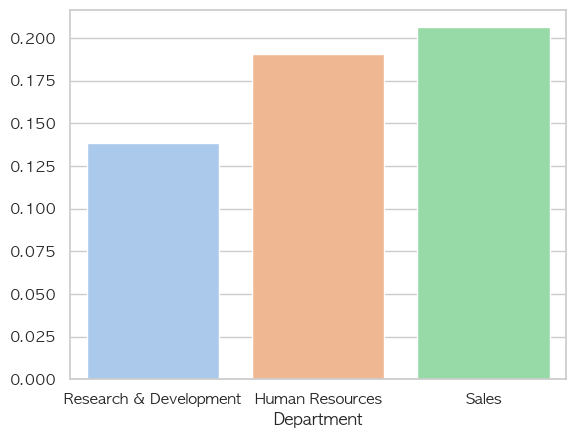

In [166]:
# 퇴사율
rate=df.groupby("Department")["Attrition"].mean().sort_values()
sns.barplot(y=rate.values, x=rate.index, palette="pastel")

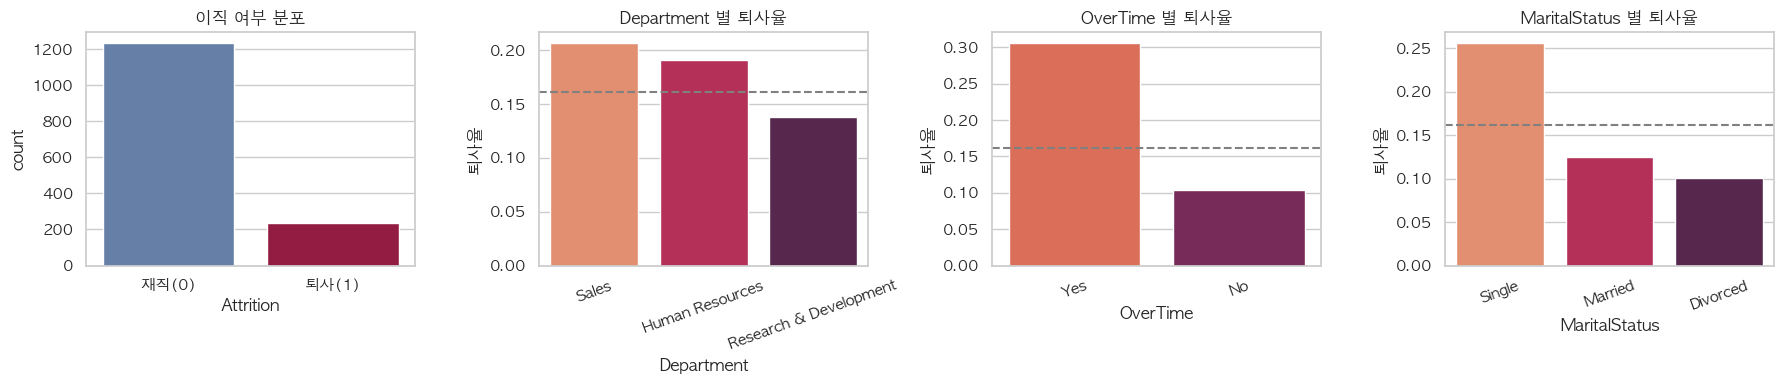

In [144]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

sns.countplot(data=df, x="Attrition", ax=axes[0], palette=["#5b7cb2", "#a5093b"])
axes[0].set_title("이직 여부 분포")
axes[0].set_xticklabels(["재직(0)", "퇴사(1)"])

for ax, col in zip(axes[1:], ["Department", "OverTime", "MaritalStatus"]):
    rate = df.groupby(col)["Attrition"].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, ax=ax, palette="rocket_r")
    ax.axhline(df["Attrition"].mean(), color="gray", linestyle="--", label="lw=1")
    ax.set_title(f"{col} 별 퇴사율")
    ax.set_ylabel("퇴사율")
    ax.tick_params(axis="x", rotation=20)
    
plt.tight_layout()
plt.show()

<Axes: xlabel='Attrition', ylabel='count'>

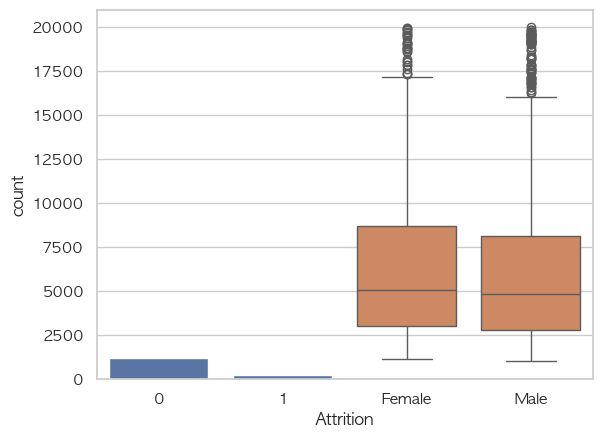

In [145]:
sns.countplot(data=df, x="Attrition")
sns.boxplot(data=df, x="Gender", y="Income_M")

In [146]:
# TODO: 1행 4열의 subplot 을 만들어 아래를 그려라
#   [0] Attrition 의 countplot (x축 라벨을 '재직(0)', '퇴사(1)' 로 바꿀 것)
#   [1] Department 별 평균 퇴사율 막대그래프
#   [2] OverTime  별 평균 퇴사율 막대그래프
#   [3] MaritalStatus 별 평균 퇴사율 막대그래프
#   힌트: df.groupby(col)["Attrition"].mean() 이 곧 그 집단의 퇴사율이다
#   힌트: 전체 평균 퇴사율을 axhline 으로 그려 두면 비교가 쉽다


### 실습 3-5. 시각화 (2) — 수치형 속성의 분포 차이

In [147]:
# TODO: Age, Income_M, YearsAtCompany, Dist 에 대해
#       이직 여부(Attrition)별 boxplot 을 1행 4열로 그려라.
#       그리고 groupby("Attrition") 로 네 컬럼의 평균을 비교 출력하라.

<Axes: xlabel='Attrition', ylabel='Income_M'>

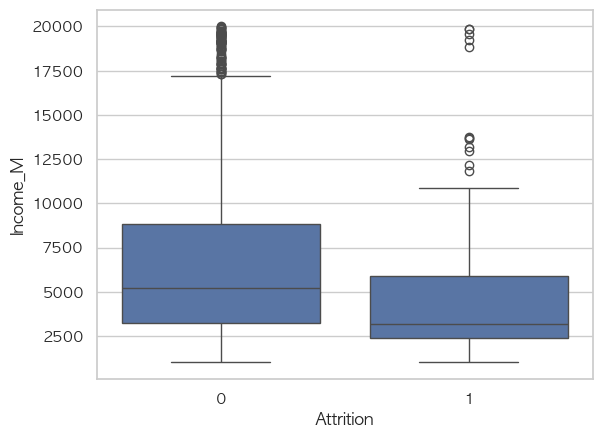

In [148]:
sns.boxplot(data=df, x="Attrition", y="Income_M")

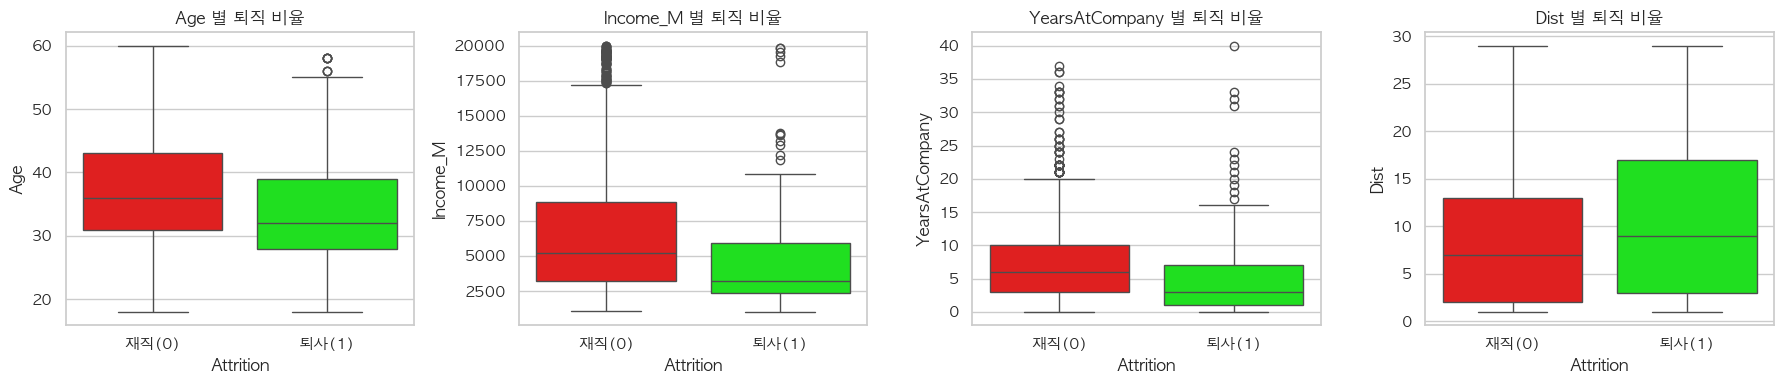

In [152]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, ["Age", "Income_M", "YearsAtCompany", "Dist"]):
    sns.boxplot(data=df, x="Attrition", y=col, ax=ax, palette=["#ff0000", "#00ff00"])
    ax.set_title(f"{col} 별 퇴직 비율")
    ax.set_xticklabels(["재직(0)", "퇴사(1)"])
plt.tight_layout()
plt.show()

### 실습 3-6. 시각화 (3) — 속성 간 상관관계와 결합 분포

In [153]:
# TODO: df.corr(numeric_only=True) 로 상관행렬을 구해 heatmap 으로 그려라.
#       이어서 Attrition 과의 상관계수를 절댓값 기준 내림차순으로 출력하라.
#       힌트: corr["Attrition"].drop("Attrition").sort_values(key=abs, ascending=False)
df.corr(numeric_only=True)

,Age,Attrition,Dist,Education,Env_Satisfaction,JobLevel,JobSatisfaction,Income_M,Companies,p_SalaryHike,Performance,RelationshipSatisfaction,StockOption,WorkLifeBalance,YearsAtCompany,YearsSinceLastPromotion
Age,1.000000,-0.159205,-0.001686,0.208034,0.010146,0.509604,-0.004892,0.497855,0.299635,0.003634,0.001904,0.053535,0.037510,-0.021490,0.311309,0.216513
Attrition,-0.159205,1.000000,0.077924,-0.031373,-0.103369,-0.169105,-0.103481,-0.159840,0.043494,-0.013478,0.002889,-0.045872,-0.137145,-0.063939,-0.134392,-0.033019
Dist,-0.001686,0.077924,1.000000,0.021042,-0.016075,0.005303,-0.003669,-0.017014,-0.029251,0.040235,0.027110,0.006557,0.044872,-0.026556,0.009508,0.010029
Education,0.208034,-0.031373,0.021042,1.000000,-0.027128,0.101589,-0.011296,0.094961,0.126317,-0.011111,-0.024539,-0.009118,0.018422,0.009819,0.069114,0.054254
Env_Satisfaction,0.010146,-0.103369,-0.016075,-0.027128,1.000000,0.001212,-0.006784,-0.006259,0.012594,-0.031701,-0.029548,0.007665,0.003432,0.027627,0.001458,0.016194
JobLevel,0.509604,-0.169105,0.005303,0.101589,0.001212,1.000000,-0.001944,0.950300,0.142501,-0.034730,-0.021222,0.021642,0.013984,0.037818,0.534739,0.353885
JobSatisfaction,-0.004892,-0.103481,-0.003669,-0.011296,-0.006784,-0.001944,1.000000,-0.007157,-0.055699,0.020002,0.002297,-0.012454,0.010690,-0.019459,-0.003803,-0.018214
Income_M,0.497855,-0.159840,-0.017014,0.094961,-0.006259,0.950300,-0.007157,1.000000,0.149515,-0.027269,-0.017120,0.025873,0.005408,0.030683,0.514285,0.344978
Companies,0.299635,0.043494,-0.029251,0.126317,0.012594,0.142501,-0.055699,0.149515,1.000000,-0.010238,-0.014095,0.052733,0.030075,-0.008366,-0.118421,-0.036814
p_SalaryHike,0.003634,-0.013478,0.040235,-0.011111,-0.031701,-0.034730,0.020002,-0.027269,-0.010238,1.000000,0.773550,-0.040490,0.007528,-0.003280,-0.035991,-0.022154


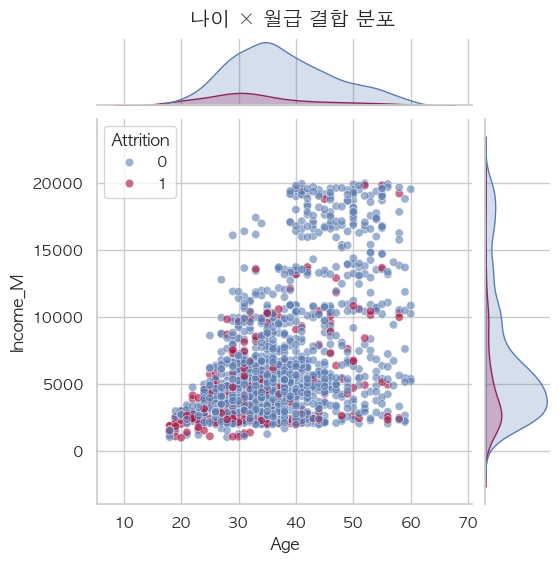

In [154]:
sns.jointplot(data=df, x="Age", y="Income_M", hue="Attrition",
              palette=["#5B7CB2", "#A5093B"], height=5.5, alpha=0.6)
plt.suptitle("나이 × 월급 결합 분포", y=1.02)
plt.show()

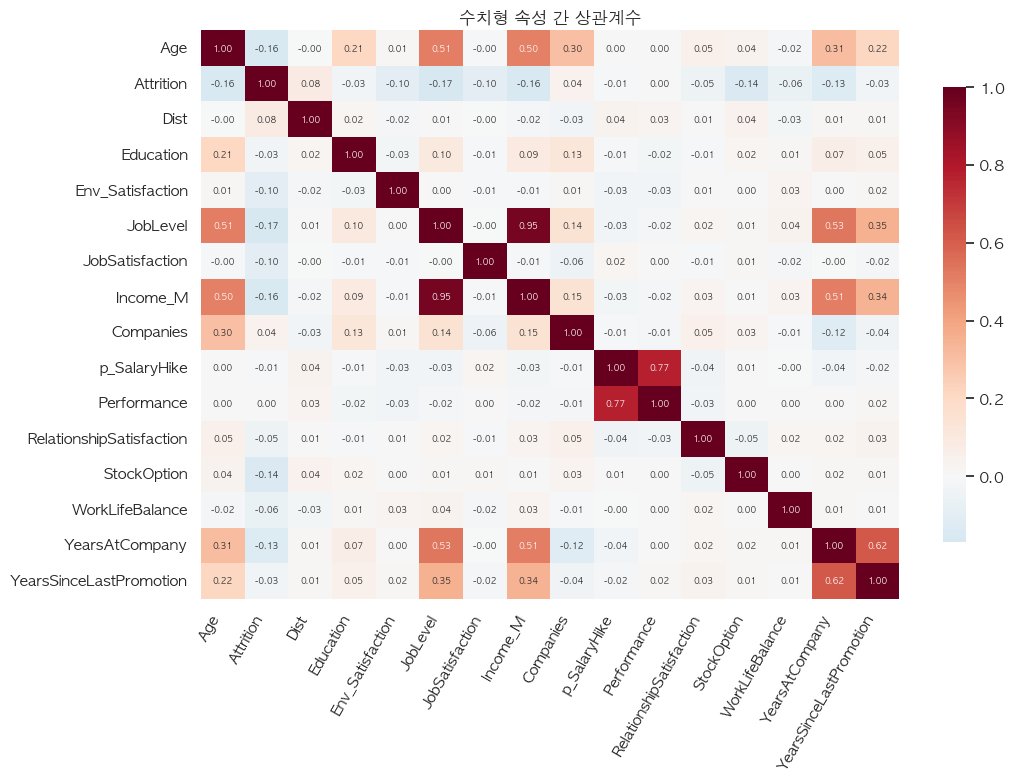

JobLevel                   -0.169
Income_M                   -0.160
Age                        -0.159
StockOption                -0.137
YearsAtCompany             -0.134
JobSatisfaction            -0.103
Env_Satisfaction           -0.103
Dist                        0.078
WorkLifeBalance            -0.064
RelationshipSatisfaction   -0.046
Companies                   0.043
YearsSinceLastPromotion    -0.033
Education                  -0.031
p_SalaryHike               -0.013
Performance                 0.003
Name: Attrition, dtype: float64


In [164]:
# sns.heatmap(df.corr(numeric_only=True), square=False, annot=True, fmt=".2f", annot_kws={"size": 6}, cmap="grey", center=True)

plt.figure(figsize=(11, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=True, square=False, fmt=".2f", annot_kws={"size": 6}, cbar_kws={"shrink": 0.8})
plt.title("수치형 속성 간 상관계수")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

# Attrition과 상관이 큰 순서
corr['Attrition']
print(corr["Attrition"].drop("Attrition").sort_values(key=abs, ascending=False).round(3))

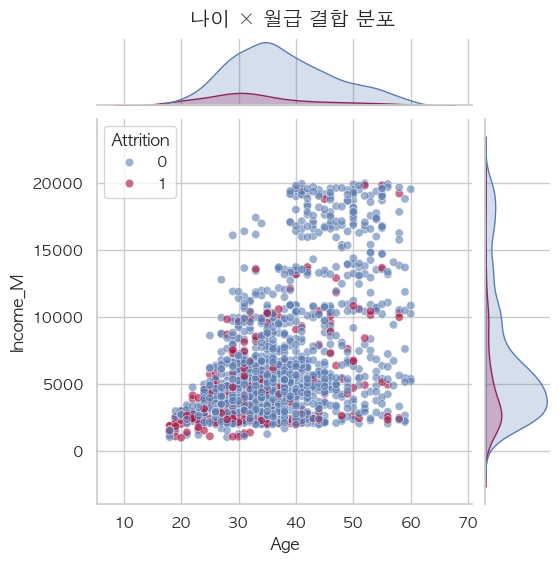

In [163]:
sns.jointplot(data=df, x="Age", y="Income_M", hue="Attrition",
              palette=["#5B7CB2", "#A5093B"], height=5.5, alpha=0.6)
plt.suptitle("나이 × 월급 결합 분포", y=1.02)
plt.show()

---
## 3-D. 클래스 불균형 · 데이터 품질 · 민감 속성

이 절에서 확인할 수치 하나가 3·4차시의 모델 훈련 방식과 평가 지표 선택을 바꾸게 된다.
무엇이 그 수치일지 생각하면서 아래를 실행해 보라.


### 실습 3-7. 클래스 불균형과 기준선(baseline) 확인

STEP 2 에서 미뤄 두었던 **기준선 정확도**를 실제 데이터로 계산한다.


In [165]:
# TODO: Attrition 의 클래스별 건수와 비율을 구하고,
#       '다수 클래스로만 예측했을 때의 정확도(= 기준선)' 를 출력하라.
#       그 기준선 모델의 재현율(Recall)은 얼마인가? 왜 그런지 생각해 보라.
# 전체 중에 맞은 사람의 비율이므로 비퇴사자로 확인한 사람들을 맞춘 것이다.
count=df['Attrition'].value_counts().sort_values(ascending=False)
print(f"다중 클래스로만 예측했을 때의 정확도는 {count[0]/len(df):.4f}")
print(f"다중 클래스로만 예측했을 때의 재현율은 0")

다중 클래스로만 예측했을 때의 정확도는 0.8388
다중 클래스로만 예측했을 때의 재현율은 0


### 실습 3-8. 데이터 품질 점검 — 결측 · 중복 · 이상치

처리 방법은 3차시에서 다루고, 오늘은 **무엇이 문제인지 발견하고 기록**한다.


In [171]:
# TODO: 아래 세 가지를 확인해 출력하라.
#   1) 컬럼별 결측치 개수
#   2) 완전 중복 행의 개수
#   3) 수치형 컬럼별 IQR 기준 이상치 후보 개수와 왜도(skew)
#      IQR = Q3 - Q1, 하한 = Q1 - 1.5*IQR, 상한 = Q3 + 1.5*IQR

df.isna().sum()
df.duplicated().sum()

print("\n* 이상치 후보 (IQR 기준)")
rows = []
for col in COLUMN_TYPES["num_cont"] + COLUMN_TYPES["num_disc"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr

    n_out = int(((df[col] < lo) | (df[col] > hi)).sum())

    rows.append({
        "컬럼": col,
        "Q1": q1,
        "Q3": q3,
        "하한": round(lo, 1),
        "상한": round(hi, 1),
        "이상치 후보": n_out,
        "비율": f"{n_out / len(df):.1%}",
        "왜도": round(df[col].skew(), 2)
    })
pd.DataFrame(rows)
   


* 이상치 후보 (IQR 기준)


,컬럼,Q1,Q3,하한,상한,이상치 후보,비율,왜도
0,Income_M,2911.0,8379.0,-5291.0,16581.0,114,7.8%,1.37
1,p_SalaryHike,12.0,18.0,3.0,27.0,0,0.0%,0.82
2,Age,30.0,43.0,10.5,62.5,0,0.0%,0.41
3,Dist,2.0,14.0,-16.0,32.0,0,0.0%,0.96
4,Companies,1.0,4.0,-3.5,8.5,52,3.5%,1.03
5,YearsAtCompany,3.0,9.0,-6.0,18.0,104,7.1%,1.76
6,YearsSinceLastPromotion,0.0,3.0,-4.5,7.5,107,7.3%,1.98


> **"이상치"와 "드문 정상값"은 다르다.**
> 월급이 매우 높은 임원은 이상치가 아니라 드문 정상값이다. 통계적 기준만으로 삭제하면 실제 신호를 지우게 된다.
> 아래에서 Income_M 의 상위 값이 실제로 무엇인지 확인해 보자.


In [ ]:
# Income_M 상위 이상치가 정말 '오류'인지 도메인 관점에서 확인
q1, q3 = df["Income_M"].quantile([0.25, 0.75])
hi = q3 + 1.5 * (q3 - q1)
outliers = df[df["Income_M"] > hi]
print(f"Income_M 상한 {hi:,.0f} 초과: {len(outliers)}건")
print("\n이상치 그룹의 직급(JobLevel) 분포:")
print(outliers["JobLevel"].value_counts().sort_index())
print("\n전체의 직급 분포:")
print(df["JobLevel"].value_counts().sort_index())
print("\n→ 고소득자는 대부분 상위 직급이다. 오류가 아니라 '드문 정상값' → 제거하지 않는다.")

Income_M 상한 16,581 초과: 114건

이상치 그룹의 직급(JobLevel) 분포:
JobLevel
4    45
5    69
Name: count, dtype: int64

전체의 직급 분포:
JobLevel
1    543
2    534
3    218
4    106
5     69
Name: count, dtype: int64

→ 고소득자는 대부분 상위 직급이다. 오류가 아니라 '드문 정상값' → 제거하지 않는다.


### 실습 3-9. 민감 속성과 편향 점검

인사 데이터이므로 **개인정보와 편향**은 반드시 다뤄야 한다.
민감 속성(Gender, Age, MaritalStatus)에 대해 라벨 분포를 확인하고, 5차시… 가 아니라 **4차시 공정성 평가**의 기준선을 만들어 둔다.


In [172]:
SENSITIVE = ["Gender", "MaritalStatus"]

# TODO 1) df 의 사본(df_sens)을 만들고, Age 를 [17,29,39,49,65] 구간으로 잘라
#         'Age_band' 컬럼을 추가하라 (pd.cut) — 원본 df 는 그대로 둘 것
# TODO 2) Gender, MaritalStatus, Age_band 각 그룹별로
#         인원 수 / 전체 대비 비중 / 실제 퇴사율 을 표로 출력하라
# → 이 표는 4차시 공정성 평가에서 '모델 예측'과 비교할 기준이 된다

df_sens = df.copy()
df_sens["Age_band"] = pd.cut(df_sens["Age"], bins=[17, 29, 39, 49, 65], labels=["20대이하", "30대", "40대", "50대이상"])

rows = []
for col in SENSITIVE + ["Age_band"]:
    g = df_sens.groupby(col, observed=True)["Attrition"].agg(["size", "mean"])
    for idx, r in g.iterrows():
        rows.append({
            "민감 속성": col,
            "그룹": str(idx),
            "인원": int(r["size"]),
            "비중": f"{r['size'] / len(df):.1%}",
            "실제 퇴사율": f"{r['mean']:.1%}"
        })
base = pd.DataFrame(rows)
print("전체 퇴사율:", f"{df['Attrition'].mean():.1%}")
base

전체 퇴사율: 16.1%


,민감 속성,그룹,인원,비중,실제 퇴사율
0,Gender,Female,588,40.0%,14.8%
1,Gender,Male,882,60.0%,17.0%
2,MaritalStatus,Divorced,327,22.2%,10.1%
3,MaritalStatus,Married,673,45.8%,12.5%
4,MaritalStatus,Single,470,32.0%,25.5%
5,Age_band,20대이하,326,22.2%,27.9%
6,Age_band,30대,622,42.3%,14.3%
7,Age_band,40대,349,23.7%,9.7%
8,Age_band,50대이상,173,11.8%,13.3%


> **민감 속성을 지우는 것은 해결책이 아니다.**
> Gender 컬럼을 제거해도 직무·부서·근속 패턴이 성별을 대리(proxy)한다.
> 우리가 할 수 있는 유일한 방법은 **측정하고 기록하는 것**이며, 그 결과는 4차시에서 모델 예측과 대조한다.


---
# 산출물 ③ 데이터 카드 (Data Card)

아래 셀을 실행해 데이터 카드를 자동 생성하고, 마지막의 **발견 사항 5문장**을 직접 작성하라.


In [ ]:
def make_data_card(data, types, target):
    """데이터 카드를 문자열로 생성한다."""
    lines = []
    lines.append("## 데이터 카드 (Data Card)\n")
    # TODO: 아래 항목을 채워 문자열로 만들어라
    #   - 출처 / 스냅샷
    #   - 규모 (행 × 열, 결측 건수, 중복 건수)
    #   - 라벨 분포와 소수 클래스 비율
    #   - 기준선 정확도
    #   - 유형별 컬럼 목록 (COLUMN_TYPES 활용)
    #   - 민감 속성
    return "\n".join(lines)


card = make_data_card(df, COLUMN_TYPES, TARGET)
print(card)

with open("data_card.md", "w", encoding="utf-8") as f:
    f.write(card)
print("\n→ data_card.md 저장 완료")

## 데이터 카드 (Data Card)


→ data_card.md 저장 완료


### [작성] EDA 결론 5문장 (산출물 ③의 '발견 사항')

실행 결과를 근거로, **숫자를 포함한 문장** 5개를 작성하라.
(예: "초과근무를 하는 직원의 퇴사율이 30.5%로 전체 평균의 약 2배")

1.
2.
3.
4.
5.

### [작성] 확인이 필요한 사항 (도메인 질문)

인사팀에 확인해야 할 항목을 2~3개 적어라.

-
-
-


---
# 제출

1. 모든 TODO 셀을 채우고 **런타임 → 모두 실행**이 오류 없이 끝나는지 확인한다.
2. 산출물 ①②③ (요구사항 명세 카드 · ML 문제 정의 카드 · 데이터 카드 + EDA 결론 5문장)이 모두 작성되었는지 확인한다.


## 다음 차시 (3차시) 예고

오늘 만든 **데이터 카드의 속성 유형 분류**를 실제 변환 코드로 바꾼다.
- 결측·이상치·스케일링·이산화·인코딩을 하나의 **Pipeline** 으로 묶는다
- 데이터 누수(leakage)를 막는 올바른 순서를 배운다
- 오늘 계산한 **기준선 정확도 83.9%** 를 실제로 넘어서는 모델을 만든다
